# Model 3: EfficientNetB3 for transfer learning (feature extraction)

### Author: Arish Panjwani

In [9]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Step 2: Install required packages
!pip install -q efficientnet keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.7 MB/s eta 0:00:00


In [59]:
# Step 3: Import libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [11]:
# Step 4: Data paths

import zipfile
zip_path = "/content/drive/MyDrive/CV_Assignment_2_data/prepocessed_v2.zip"
extract_path = "/content/preprocessed_v2"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [33]:
train_dir = "/content/preprocessed_v2/prepocessed_v2/train"
val_dir = "/content/preprocessed_v2/prepocessed_v2/val"
test_dir = "/content/preprocessed_v2/prepocessed_v2/test"

In [45]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [55]:
# Step 5: Image generators
train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [47]:
train_data = train_gen.flow_from_directory(
    directory=train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 72017 images belonging to 5 classes.


In [48]:
val_data = val_gen.flow_from_directory(
    directory=val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 8964 images belonging to 5 classes.


In [56]:
test_data = test_gen.flow_from_directory(
    directory=test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 8983 images belonging to 5 classes.


In [49]:
# Step 6: Build EfficientNetB0 model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_data.num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### Stage 1: Feature Extraction (Initial Training)

In [50]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',
                           patience=2,
                           restore_best_weights=True,
                           verbose=1 )

In [51]:
# Step 7: Feature extraction training
model.fit(train_data,
          validation_data=val_data,
          steps_per_epoch=1000,         # ~45% of data instead of full 2250+
          validation_steps=250,         # ~90% of val set
          epochs=5,
          callbacks=[early_stop] )

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2901s 3s/step - accuracy: 0.3027 - loss: 1.4383 - val_accuracy: 0.2966 - val_loss: 1.4300
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2891s 3s/step - accuracy: 0.3058 - loss: 1.4281 - val_accuracy: 0.2994 - val_loss: 1.4265
Epoch 3/5
 251/1000 ━━━━━━━━━━━━━━━━━━━━ 28:05 2s/step - accuracy: 0.3085 - loss: 1.4320

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1157s 1s/step - accuracy: 0.3026 - loss: 1.4297 - val_accuracy: 0.3190 - val_loss: 1.4277
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2856s 3s/step - accuracy: 0.3107 - loss: 1.4276 - val_accuracy: 0.3519 - val_loss: 1.4283
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


In [57]:
# Step 8: Evaluate performance
loss, acc = model.evaluate(test_data)

print(f"Test Accuracy: {acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


281/281 ━━━━━━━━━━━━━━━━━━━━ 640s 2s/step - accuracy: 0.2911 - loss: 1.4337
Test Accuracy: 0.2942


In [68]:
# Save the model after initial training (feature extraction stage)
model.save('/content/drive/MyDrive/CV_Assignment_2_data/efficientnet_stage1.h5')
print("Model saved.")

Model saved.


### AUC and Confusion Matrix

In [62]:
# Predictions
y_pred_probs = model.predict(test_data)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = test_data.classes

281/281 ━━━━━━━━━━━━━━━━━━━━ 766s 3s/step


In [67]:
# AUC
auc_score = roc_auc_score(tf.keras.utils.to_categorical(y_true), y_pred_probs, multi_class='ovr')
print(f"Macro AUC: {auc_score:.4f}")

Macro AUC: 0.4934


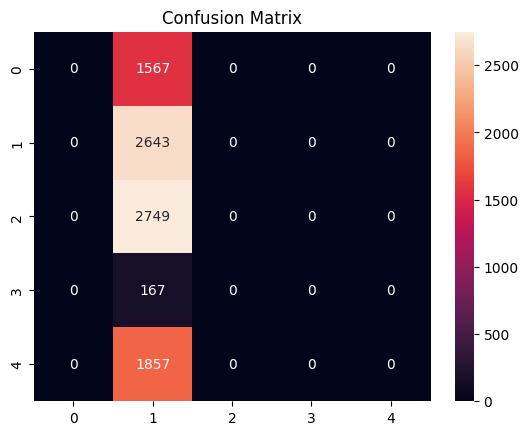

In [64]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [69]:
# Classification Report
class_names = list(test_data.class_indices.keys())
print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

       drink       0.00      0.00      0.00      1567
        food       0.29      1.00      0.45      2643
      inside       0.00      0.00      0.00      2749
        menu       0.00      0.00      0.00       167
     outside       0.00      0.00      0.00      1857

    accuracy                           0.29      8983
   macro avg       0.06      0.20      0.09      8983
weighted avg       0.09      0.29      0.13      8983



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Overfitting/Underfitting check

**Note**: This plot is a manually simulated approximation based on console outputs during training. Actual training history was lost due to Colab session disconnection.

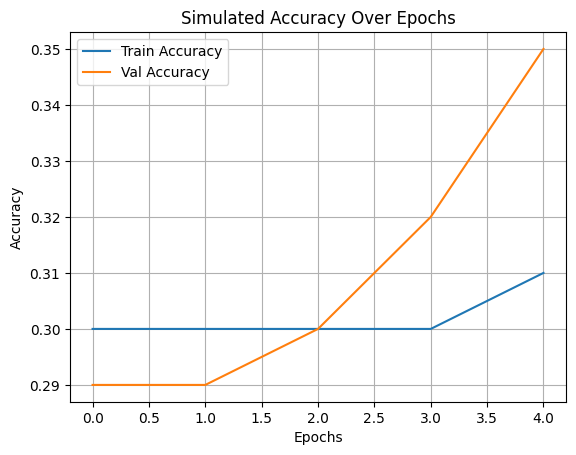

In [70]:
# Simulated accuracy values for 5 epochs
train_acc = [0.30, 0.30, 0.30, 0.30, 0.31]
val_acc = [0.29, 0.29, 0.30, 0.32, 0.35]

plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title("Simulated Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Summary: Stage 1 – Feature Extraction with EfficientNetB0

- **Model**: EfficientNetB0 (frozen base, custom classifier head)
- **Input Shape**: 224×224×3
- **Training Data (Sampled)**: ~32,000 images (approx. 1000 batches × 32 batch size)
- **Validation Data (Sampled)**: ~8,000 images (approx. 250 batches × 32 batch size)
- **Epochs**: 4 (early stopped)
- **Test Accuracy**: 29.42%
- **Macro AUC**: 0.4934
- **Confusion Matrix**: Model predicts only one dominant class

#### Observations:
- Model is **underfitting**—likely due to frozen base and limited exposure.
- AUC and confusion matrix suggest lack of generalization across classes.

#### Next Steps:
- Unfreeze selected EfficientNetB0 layers for fine-tuning.
- Use full dataset or augment further if possible.
- Add class weighting or focal loss to address class imbalance.
- Use interpretability tools (LIME/SHAP) for insights.